In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import importlib
from helpers import module_auxiliary as ma
from matplotlib_scalebar.scalebar import ScaleBar
from cil.optimisation.operators import GradientOperator # For extract edge function
import matplotlib
#matplotlib.use('Agg')
from segmentation import s3_watershed_eds
importlib.reload(s3_watershed_eds)
import matplotlib.colors as mcolors
import copy
from segmentation import s2_watershed_filter

Load XA and NA data

In [2]:
NA_surf_volume_ = np.load('/dtu-compute/msaca/cache/NA_surf1.npy')
XA_surf_volume_ = np.load('/dtu-compute/msaca/cache/XA_surf1.npy')
nz, ny, nx = np.shape(XA_surf_volume_)
subvol = [0,nz,30, 40, 0, nx]

NA_surf_volume = NA_surf_volume_[subvol[0]:subvol[1],subvol[2]:subvol[3],subvol[4]:subvol[5]]
XA_surf_volume = XA_surf_volume_[subvol[0]:subvol[1],subvol[2]:subvol[3],subvol[4]:subvol[5]]
XA, NA = s2_watershed_filter.place_medians_in_watersheds(XA_surf_volume, NA_surf_volume,
    eta_edge = 0.005,level = 0.15, conductivity = 0.5, smoothing_iter = 15, watershed_line = False)

Watershedding with level  0.15  and smoothing iter  15
Diffusion time:  41.77115035057068
Gradient time:  9.114173173904419
Watershed time:  49.00946927070618
Assignment time:  0.9817566871643066
Number of watersheds 152082


In [3]:
full_seg_, segmentation_, elem_segm_, elems_ = s3_watershed_eds.get_segmentation_from_watersheds(
    thresholds = np.array([13, 13, 13, 8 , 18, 8, 28, 10, 3 , 28, 8, 11 , 90, 8, 3]),
    output=True)
segmentation = {}
for key in segmentation_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(segmentation_[key].astype(np.float32))
        segmentation[key] = s3_watershed_eds.transform_eds(segmentation_[key].astype(np.float32))

elem_segm = {}
for key in elem_segm_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elem_segm_[key].astype(np.float32))
        elem_segm[key] = s3_watershed_eds.transform_eds(elem_segm_[key].astype(np.float32))

elems = {}
for key in elems_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elems_[key].astype(np.float32))
        elems[key] = s3_watershed_eds.transform_eds(elems_[key].astype(np.float32))

moving = sitk.GetImageFromArray(full_seg_)
full_seg = s3_watershed_eds.transform_eds(full_seg_)

In [4]:
def plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = None,transparencies = [0.7, 0.5]):
    plt.close('all)')
    Ns = np.max(ground_truth_seg)
    if class_labels is None:
        class_labels = "".join(map(str, range(0, Ns)))
    # Add black as the first color

    colors_d = [
        (0, 0, 255),      # Blue Plagio
        (128, 0, 128),    # Purple Alk
        (255, 50, 150),   # Pink   #cpx
        (0, 255, 0),      # Green   # opx
        (255, 165, 0),    # Orange     #apatite
        (160, 255, 0),    # Brown Ilminite
        (0, 170, 255),    # light blue, chromite
        (255, 0, 0),    #  pyrite   
        (255, 0, 255),   # Magenta, Baddelyite
        (0, 255, 255) # Cyan
    ]

    # Convert RGB to normalized values and prepend a transparent color
    colors_d = [(0, 0, 0, 0.7)] + [(r/255, g/255, b/255, 0.5) for r, g, b in colors_d[:Ns]]

    # Create the colormap
    cmap_d = mcolors.ListedColormap(colors_d)
    boundaries = np.arange(-0.5, Ns+1, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
    norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
    # Plot the matrix with the custom colormap
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(background, cmap="gray", vmin = 0.01, vmax = 0.04)  # Adjust alpha for blending

    im = ax.imshow(ground_truth_seg, cmap=cmap_d, norm=norm)

    # Create a colorbar next to the plot
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
    bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
    # Manually add text labels next to the colorbar
    cbar_ax = cbar.ax  # Get the colorbar axis
    for i, label in enumerate(class_labels):
        y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
        cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

    cbar_ax.set_frame_on(False)  # Remove border

    # Overlay the grayscale image using transparency
    
    #ax.axis('off')
    # Add scale bar (adjust values based on real-world scale)
    scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
    ax.add_artist(scalebar)
    fig.tight_layout()
    if test_seg is not None:
        temp = ground_truth_seg.copy()
        temp[test_seg.astype(bool)] = Ns+1
        colors_d = [(r, g, b, alpha) for r, g, b, alpha in colors_d] + [(1.0, 1.0, 0.0, 0.35)]
        cmap_d = mcolors.ListedColormap(colors_d)
        boundaries = np.arange(-0.5, Ns+2, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
        norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
        # Plot the matrix with the custom colormap
        fig2, ax2 = plt.subplots(figsize=(10, 10))
        ax2.imshow(background, cmap="gray", vmin = 0.01, vmax = 0.04)  # Adjust alpha for blending
        im2 = ax2.imshow(temp, cmap=cmap_d, norm=norm)

        # Create a colorbar next to the plot
        cbar = fig2.colorbar(im2, ax=ax2, ticks=[], fraction=0.05, pad=0.04)
        bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
        # Manually add text labels next to the colorbar
        cbar_ax = cbar.ax  # Get the colorbar axis
        class_labels.append('Test_seg')
        for i, label in enumerate(class_labels):
            y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
            cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

        cbar_ax.set_frame_on(False)  # Remove border
        # Overlay the grayscale image using transparency
        #ax.axis('off')
        # Add scale bar (adjust values based on real-world scale)
        scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
        ax2.add_artist(scalebar)
        fig2.tight_layout()
        fig2.show()
        return fig, fig2
    else:
        return fig

In [5]:
def create_segmentation(i1, i2, t1, t2, b1, b2,mask):
    """Create segmentation mask with thresholds and inequality directions"""
    segm1 = i1 < t1 if b1 else i1 > t1
    segm2 = i2 < t2 if b2 else i2 > t2
    segm = np.logical_and(segm1,segm2)
    segm[np.logical_not(mask)] = False
    return segm


def create_segmentation_x(i_x, t_x, b_x, mask):
    """Create segmentation mask for i_x"""
    segm_x = i_x < t_x if b_x else i_x > t_x
    segm_x[np.logical_not(mask)] = False
    return segm_x

def class_balance_penalty(segm, mask, lam=1,center = 0.5, power = 6, narrowness = 1):
    """Penalizes unbalanced segmentation inside the mask."""
    segm_in_mask = segm[mask]  # Only consider pixels inside the stone
    p1 = np.mean(segm_in_mask)  # Fraction of pixels classified as True
    penalty =  lam * (narrowness*2*np.abs((p1 - center)))**power
    return penalty

def dice_loss(segm, segm_x):
    intersection = np.sum(segm * segm_x)
    return 1 - (2 * intersection + 1e-6) / (np.sum(segm) + np.sum(segm_x) + 1e-6)


def symmetric_dice_loss(segm1, segm2):
    """Computes a symmetric version of Dice loss."""
    intersection = np.sum(segm1 * segm2)
    intersection_complement = np.sum((1 - segm1) * (1 - segm2))
    total_pixels = segm1.size  # Total number of pixels in the image

    return 1 - (intersection + intersection_complement) / (2 * total_pixels)

In [6]:
from scipy.optimize import differential_evolution

i1 = XA[:,7]
i2 = NA[:,7]
i_x = elems['Ca']

i1 = i1[200:-600,200:-400]
i2 = i2[200:-600,200:-400]
i_x = i_x[200:-600,200:-400]
i_x = i_x/1000

mask = np.logical_or(i1>0.005, i2>0.0)

def loss_function(params):
    t1, t2, t_x, b1, b2 = params
    segm = create_segmentation(i1, i2, t1, t2, round(b1), round(b2), mask)
    segm_x = create_segmentation_x(i_x, t_x, 0, mask)
    r1 = class_balance_penalty(segm, mask, lam=1,center = 0.50, power = 100, narrowness = 3)
    r2 = class_balance_penalty(segm_x, mask, lam=1,center = 0.50, power = 100, narrowness = 3)
    return symmetric_dice_loss(segm, segm_x) + r1 + r2

bounds = [(0, 0.06),  # Bounds for t1
          (0, 0.06),  # Bounds for t2
          (0.00, 0.1), # Bounds for t_x
          (0, 1), (0, 1)]  # Binary variables (will be rounded)

result = differential_evolution(
    loss_function, 
    bounds, 
    strategy='rand1bin',  # Try 'rand1bin', 'best1bin', or 'best1exp'
    popsize=15,            # Increase population size (default is 15)
    mutation=(0.8, 1.2),    # Tune mutation range
    recombination=0.7,      # Adjust recombination
    maxiter=20,            # Increase max iterations
    disp=True,               # Show progress
    tol = 1e-4
)
t1_opt, t2_opt, t_x_opt, b1_opt, b2_opt= result.x


differential_evolution step 1: f(x)= 4.1498413998820475e+22
differential_evolution step 2: f(x)= 4.1498413998820475e+22
differential_evolution step 3: f(x)= 4.1498413998820475e+22
differential_evolution step 4: f(x)= 4.1498413998820475e+22
differential_evolution step 5: f(x)= 608363709095392.9
differential_evolution step 6: f(x)= 8916824086.099821
differential_evolution step 7: f(x)= 871165019.8552201
differential_evolution step 8: f(x)= 871165019.8552201
differential_evolution step 9: f(x)= 871165019.8552201
differential_evolution step 10: f(x)= 871165019.8552201
differential_evolution step 11: f(x)= 871165019.8552201
differential_evolution step 12: f(x)= 0.7111928138023437
differential_evolution step 13: f(x)= 0.7111928138023437
differential_evolution step 14: f(x)= 0.7111928138023437
differential_evolution step 15: f(x)= 0.7111928138023437
differential_evolution step 16: f(x)= 0.7111928138023437
differential_evolution step 17: f(x)= 0.7111928138023437
differential_evolution step 18:

In [ ]:
print(t1_opt)
print(t2_opt)
print(t_x_opt)
print(b1_opt)
print(b2_opt)

0.028847247408939434
0.00041592323556308847
0.009296829748737988
0.8906364680689528
0.4052210247702372


0.5326093476592146
0.5326093476592146


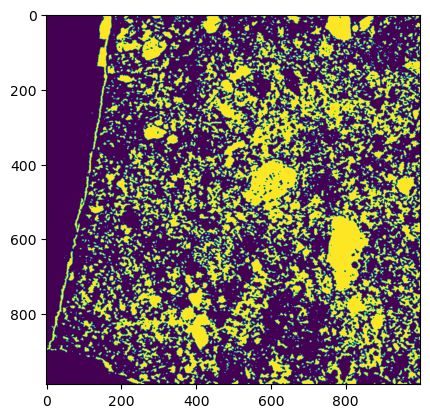

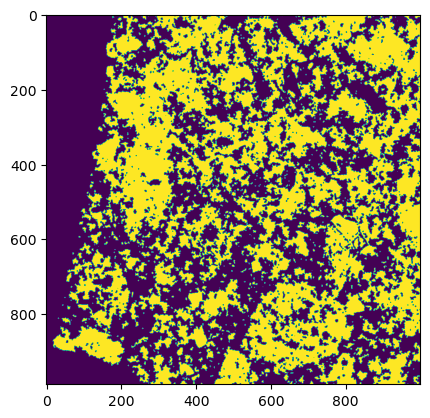

segm class mean 0.3689159997786764
segm class mean 0.5158511756688546
0.335 0.665


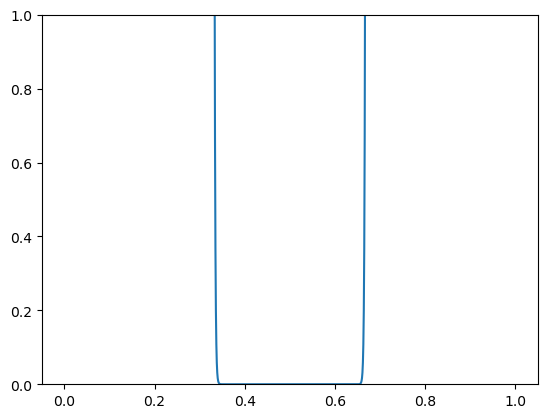

In [11]:
segm = create_segmentation(i1, i2, t1_opt, t2_opt, round(b1_opt), round(b2_opt), mask)
segm_x = create_segmentation_x(i_x, t_x_opt, 0, mask)
print(dice_loss(segm, segm_x))
#segm = create_segmentation(i1, i2, 0.04, 0.04, round(b1_opt), round(b2_opt), mask)
#segm_x = create_segmentation_x(i_x, 0.00, 0, mask)
print(dice_loss(segm, segm_x))
plt.imshow(segm)
plt.show()
plt.imshow(segm_x)
plt.show()
segm_in_mask = segm[mask]  # Only consider pixels inside the stone
p1 = np.mean(segm_in_mask)
print('segm class mean',p1)
segm_in_mask = segm_x[mask]  # Only consider pixels inside the stone
p1 = np.mean(segm_in_mask)
print('segm class mean',p1)
lam = 1
p1 = np.linspace(0,1,1001)
plt.plot(p1, lam * (3*2*np.abs((p1 - 0.50)))**100)
plt.ylim([0,1])

p1_mask = lam * (3*2*np.abs((p1 - 0.50)))**100<0.5
print(np.min(p1[p1_mask]), np.max(p1[p1_mask]))

In [12]:
background = XA[:,7,:]
ground_truth_seg = full_seg
test_seg = segm.astype(np.uint8)
ground_truth_seg = segm_x.astype(np.uint8)
class_labels=['Background', 'Feldspar an-al']#, 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
fig, fig2= plot_segmentations(background[200:-600,200:-400], ground_truth_seg, test_seg = test_seg, class_labels = class_labels,transparencies = [0.0, 1])
plt.close('all')

/tmp/pbs.506981.hnode41/ipykernel_3111775/886967950.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


In [ ]:
narrowness = 2
center = 0.5
power = 100

val_opt = loss_function((t1_opt, t2_opt, t_x_opt, b1_opt, b2_opt))
segm_in_mask = segm[mask]  # Only consider pixels inside the stone
p = np.mean(segm_in_mask)
segm_in_mask = segm_x[mask]  # Only consider pixels inside the stone
p_x = np.mean(segm_in_mask)


p1 = np.linspace(0,1,1001)
p1_mask = lam * (narrowness*2*np.abs((p1 - center)))**power<0.5
interval = [np.min(p1[p1_mask]), np.max(p1[p1_mask])]

b1_opt_str = '<' if round(b1_opt) else '>'
b2_opt_str = '<' if round(b2_opt) else '>'
text_str = "Comparison of EDS segmentation with XA_NA segmentation. Optimizing over thresholds values: \n XA th: "\
         + b1_opt_str +" " + str(round(t1_opt,4)) + " NA th: " + b2_opt_str + " " + str(round(t2_opt,4)) +\
         " Constraint: Percentage belonging to true class: " + str(interval) +\
        " \n Mean percentage in EDS class: " + str(round(p_x,4)) + ". Mean percentage in XA_NA class: " + str(round(p,4)) +\
        " \nOptimization using symmetric dice loss. Optimal value: " + str(round(val_opt,4))
        
ax = fig2.gca()
# Position the text inside the plot
ax.text(0.5, -0.1, text_str, transform=ax.transAxes, ha='center', va='center',
        fontsize=10, bbox=dict(facecolor='gray', alpha=0.5, edgecolor='red'))
display(fig2)

In [13]:
lam = 1
center = 0.5
power = 100
narrowness= 2
element = 'Al'
def plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = None,transparencies = [0.7, 0.5]):
    plt.close('all)')
    Ns = np.max(ground_truth_seg)
    if class_labels is None:
        class_labels = "".join(map(str, range(0, Ns)))
    # Add black as the first color

    colors_d = [
        (0, 0, 255),      # Blue Plagio
        (0, 255, 0),    # Purple Alk
        (255, 50, 150),   # Pink   #cpx
        (0, 255, 0),      # Green   # opx
        (255, 165, 0),    # Orange     #apatite
        (160, 255, 0),    # Brown Ilminite
        (0, 170, 255),    # light blue, chromite
        (255, 0, 0),    #  pyrite   
        (255, 0, 255),   # Magenta, Baddelyite
        (0, 255, 255) # Cyan
    ]

    # Convert RGB to normalized values and prepend a transparent color
    colors_d = [(0, 0, 0, 0.7)] + [(r/255, g/255, b/255, 0.5) for r, g, b in colors_d[:Ns+1]]

    # Create the colormap
    cmap_d = mcolors.ListedColormap(colors_d)
    boundaries = np.arange(-0.5, Ns+1, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
    norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
    # Plot the matrix with the custom colormap
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(background, cmap="gray", vmin = 0.01, vmax = 0.04)  # Adjust alpha for blending

    im = ax.imshow(ground_truth_seg, cmap=cmap_d, norm=norm)

    # Create a colorbar next to the plot
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
    bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
    # Manually add text labels next to the colorbar
    cbar_ax = cbar.ax  # Get the colorbar axis
    for i, label in enumerate(class_labels):
        y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
        cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

    cbar_ax.set_frame_on(False)  # Remove border

    # Overlay the grayscale image using transparency
    
    #ax.axis('off')
    # Add scale bar (adjust values based on real-world scale)
    scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
    ax.add_artist(scalebar)
    fig.tight_layout()
    if test_seg is not None:
        temp = ground_truth_seg.copy()
        temp[test_seg.astype(bool)] = Ns+2
        temp[test_seg.astype(bool)*ground_truth_seg.astype(bool)] = Ns+1
        colors_d = [(r, g, b, alpha) for r, g, b, alpha in colors_d] + [(1.0, 1.0, 0.0, 0.35)]
        cmap_d = mcolors.ListedColormap(colors_d)
        boundaries = np.arange(-0.5, Ns+3, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
        norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
        # Plot the matrix with the custom colormap
        fig2, ax2 = plt.subplots(figsize=(10, 10))
        ax2.imshow(background, cmap="gray", vmin = 0.01, vmax = 0.04)  # Adjust alpha for blending
        im2 = ax2.imshow(temp, cmap=cmap_d, norm=norm)

        # Create a colorbar next to the plot
        cbar = fig2.colorbar(im2, ax=ax2, ticks=[], fraction=0.05, pad=0.04)
        bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
        # Manually add text labels next to the colorbar
        cbar_ax = cbar.ax  # Get the colorbar axis
        class_labels.append('Test_seg')
        for i, label in enumerate(class_labels):
            y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
            cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

        cbar_ax.set_frame_on(False)  # Remove border
        # Overlay the grayscale image using transparency
        #ax.axis('off')
        # Add scale bar (adjust values based on real-world scale)
        scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
        ax2.add_artist(scalebar)
        fig2.tight_layout()
        plt.close('all')
        return fig, fig2
    else:
        return fig



def create_segmentation(i1, i2, t1, t2, b1, b2,mask):
    """Create segmentation mask with thresholds and inequality directions"""
    segm1 = i1 < t1 if b1 else i1 > t1
    segm2 = i2 < t2 if b2 else i2 > t2
    segm = np.logical_and(segm1,segm2)
    segm[np.logical_not(mask)] = False
    return segm


def create_segmentation_x(i_x, t_x, b_x, mask):
    """Create segmentation mask for i_x"""
    segm_x = i_x < t_x if b_x else i_x > t_x
    segm_x[np.logical_not(mask)] = False
    return segm_x

def class_balance_penalty(segm, mask, lam=1,center = 0.5, power = 6, narrowness = 1):
    """Penalizes unbalanced segmentation inside the mask."""
    segm_in_mask = segm[mask]  # Only consider pixels inside the stone
    p1 = np.mean(segm_in_mask)  # Fraction of pixels classified as True
    penalty =  lam * (narrowness*2*np.abs((p1 - center)))**power
    return penalty

def dice_loss(segm, segm_x):
    intersection = np.sum(segm * segm_x)
    return 1 - (2 * intersection + 1e-6) / (np.sum(segm) + np.sum(segm_x) + 1e-6)


def symmetric_dice_loss(segm1, segm2):
    """Computes a symmetric version of Dice loss."""
    intersection = np.sum(segm1 * segm2)
    intersection_complement = np.sum((1 - segm1) * (1 - segm2))
    total_pixels = segm1.size  # Total number of pixels in the image

    return 1 - (intersection + intersection_complement) / (2 * total_pixels)




from scipy.optimize import differential_evolution

i1 = XA[:,7]
i2 = NA[:,7]
i_x = elems[element]

i1 = i1[200:-600,200:-400]
i2 = i2[200:-600,200:-400]
i_x = i_x[200:-600,200:-400]
i_x = i_x/1000

mask = np.logical_or(i1>0.005, i2>0.0)

def loss_function(params):
    t1, t2, t_x, b1, b2 = params
    segm = create_segmentation(i1, i2, t1, t2, round(b1), round(b2), mask)
    segm_x = create_segmentation_x(i_x, t_x, 0, mask)
    r1 = class_balance_penalty(segm, mask, lam=1,center = center, power = 100, narrowness = narrowness)
    r2 = class_balance_penalty(segm_x, mask, lam=1,center = center, power = 100, narrowness = narrowness)
    return symmetric_dice_loss(segm, segm_x) + r1 + r2

bounds = [(0, 0.06),  # Bounds for t1
          (0, 0.06),  # Bounds for t2
          (0.00, 0.1), # Bounds for t_x
          (0, 1), (0, 1)]  # Binary variables (will be rounded)

result = differential_evolution(
    loss_function, 
    bounds, 
    strategy='rand1bin',  # Try 'rand1bin', 'best1bin', or 'best1exp'
    popsize=15,            # Increase population size (default is 15)
    mutation=(0.8, 1.2),    # Tune mutation range
    recombination=0.7,      # Adjust recombination
    maxiter=30,            # Increase max iterations
    disp=False,               # Show progress
    tol = 1e-4
)
t1_opt, t2_opt, t_x_opt, b1_opt, b2_opt= result.x

segm = create_segmentation(i1, i2, t1_opt, t2_opt, round(b1_opt), round(b2_opt), mask)
segm_x = create_segmentation_x(i_x, t_x_opt, 0, mask)

background = XA[:,7,:]
ground_truth_seg = full_seg
test_seg = segm.astype(np.uint8)
ground_truth_seg = segm_x.astype(np.uint8)
class_labels=['Background', element + ' (EDS)', 'Both']#, 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
fig, fig2= plot_segmentations(background[200:-600,200:-400], ground_truth_seg, test_seg = test_seg, class_labels = class_labels)


val_opt = loss_function((t1_opt, t2_opt, t_x_opt, b1_opt, b2_opt))
segm_in_mask = segm[mask]  # Only consider pixels inside the stone
p = np.mean(segm_in_mask)
segm_in_mask = segm_x[mask]  # Only consider pixels inside the stone
p_x = np.mean(segm_in_mask)


p1 = np.linspace(0,1,1001)
p1_mask = lam * (narrowness*2*np.abs((p1 - center)))**power<0.5
interval = [round(np.min(p1[p1_mask]),3), round(np.max(p1[p1_mask]),3)]

b1_opt_str = '<' if round(b1_opt) else '>'
b2_opt_str = '<' if round(b2_opt) else '>'
text_str = "Comparison of EDS segmentation with XA_NA segmentation. Optimizing over thresholds values: \n XA th: "\
         + b1_opt_str +" " + str(round(t1_opt,4)) + " NA th: " + b2_opt_str + " " + str(round(t2_opt,4)) +\
         " Constraint: Percentage belonging to true class: " + str(interval) +\
        " \n Mean percentage in EDS class: " + str(round(p_x,4)) + ". Mean percentage in XA_NA class: " + str(round(p,4)) +\
        " \nOptimization using symmetric dice loss. Optimal value: " + str(round(val_opt,4))
        
ax = fig2.gca()
# Position the text inside the plot
ax.text(0.5, -0.1, text_str, transform=ax.transAxes, ha='center', va='center',
        fontsize=10, bbox=dict(facecolor='gray', alpha=0.5, edgecolor='red'))


Text(0.5, -0.1, 'Comparison of EDS segmentation with XA_NA segmentation. Optimizing over thresholds values: \n XA th: < 0.0276 NA th: < 0.049 Constraint: Percentage belonging to true class: [0.252, 0.748] \n Mean percentage in EDS class: 0.3016. Mean percentage in XA_NA class: 0.2818 \nOptimization using symmetric dice loss. Optimal value: 0.6177')

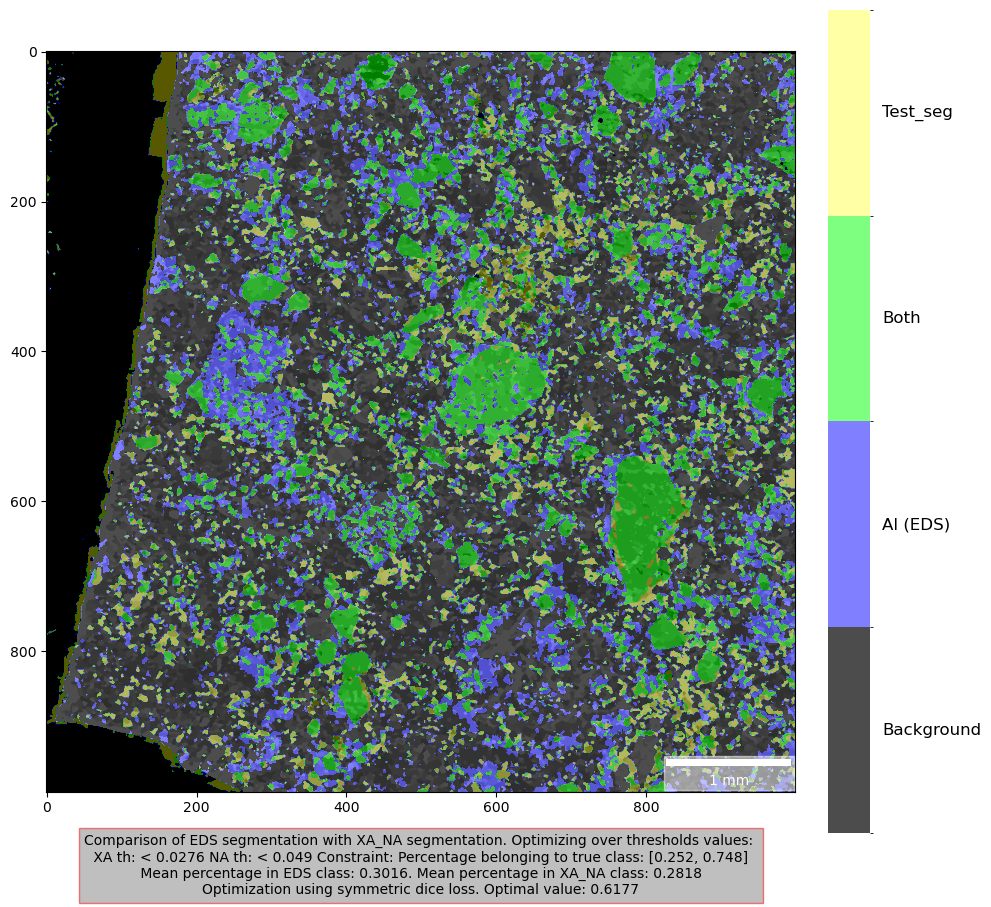

In [14]:

display(fig2)

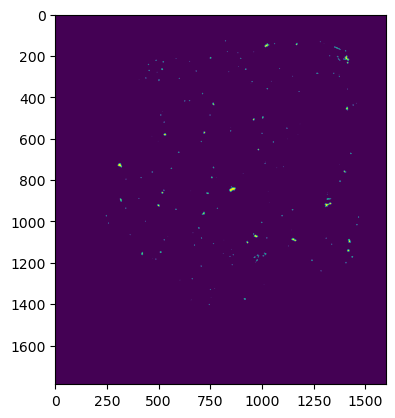

In [15]:
plt.imshow(elems['Ti']>20)
plt.clim([0,1])
plt.show()
#['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
#[13,    20,    17,   24,   26,   19,   12,   11,   28,    8,   15,   16,   14,   22,   40]
# Cl Z=17: 10 is LB for high conc #(this is an asymmetric element)
# Cr: Z=24 2 is LB for high conc (antisymmetric). (Lower than 2 matches feldspars)
# Fe: Z=26 symmetric: Lower than 15 marks regions that match feldspars, higher than 18 marks
# K: Z=19 Symmetric: Regions higher than 4 match certain regions. Specific regions have very low K (<3)
# Mg: Z=12 Symmetric: High Mg regions: Higher than 45. Low regions: Lower than 35. Matches feldspar
# Na: Z=11 Symmetric: High regions overlap with feldspar (>10), low regions overlap with certain materials
# Ni: Z=28 (Not interesting)
# O:  Z=8  Symmetric: Regions lower than 55 seems to overlap with some feldspars
# P: Z=15: Antisymmetric: High areas are small and distinct (>3)
# S: Z=16: Antisymmetric: Dstinct areas over 6
# Si: Z=14: Symmetric Distinct areas below 80 (that overlap with high iron areas). Areas over ~85 overlap with feldspars
# Ti: Z=22: Symmetric: Distinct areas over 7, distinct areas below 7, overlapping with feldspars


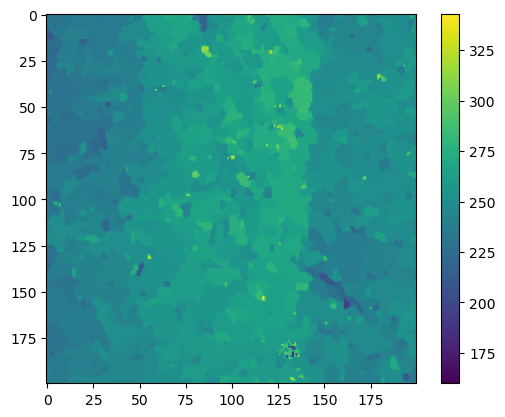

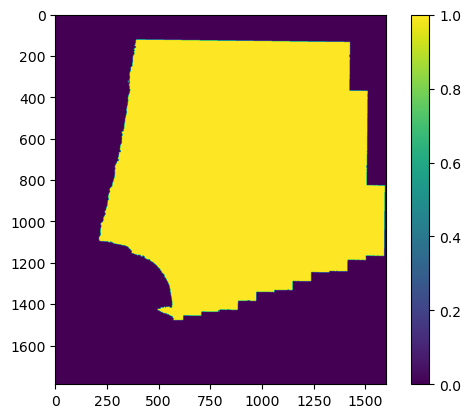

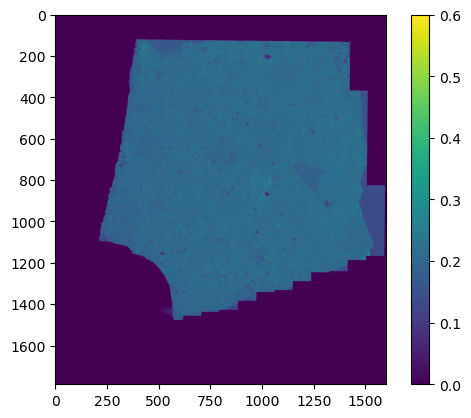

In [16]:
elems_n = copy.deepcopy(elems)
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
sum_elems = np.zeros(np.shape(elems['Al']))
for element in elements:
    sum_elems = sum_elems + elems[element]

mask = sum_elems>10
for element in elements:
    elems_n[element] = elems_n[element].astype(np.float32)
    elems_n[element][mask] = elems[element][mask]/sum_elems[mask]
    elems_n[element][np.logical_not(mask)] = 0

plt.imshow(sum_elems[400:600,400:600])
plt.colorbar()
plt.show()

plt.imshow(mask)
plt.colorbar()
plt.show()

plt.imshow(elems_n['O'])
plt.clim([0,0.6])
plt.colorbar()
plt.show()



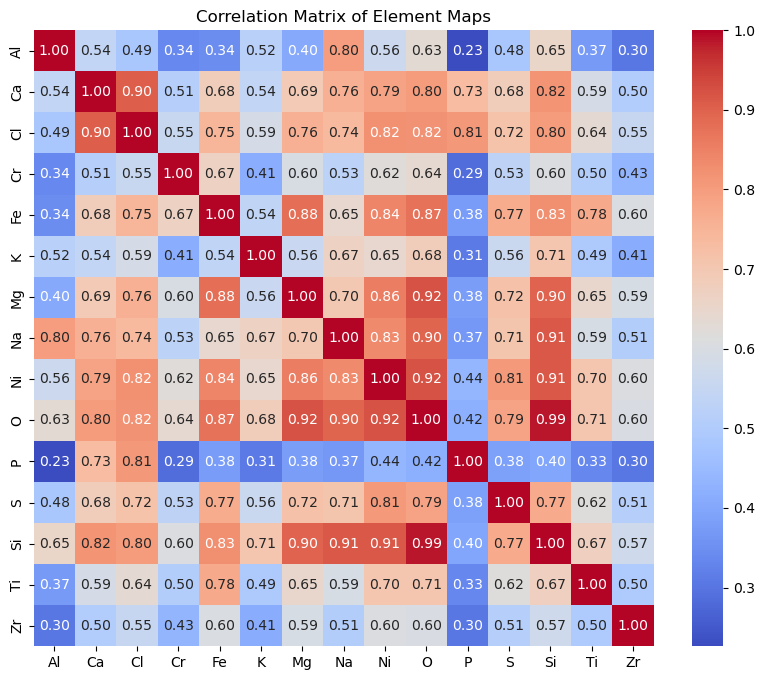

In [17]:

!pip install seaborn
import seaborn as sns
# Flatten each 2D array and store in a matrix
labels = list(elems_n.keys())
data = np.array([elems[key].flatten() for key in labels])

# Compute correlation matrix
corr_matrix = np.corrcoef(data)

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Element Maps")
plt.show()


In [ ]:
# Approximate atomic weights (g/mol)
atomic_weights = {
    "Al": 26.98, "Ca": 40.08, "Cl": 35.45, "Cr": 51.99, "Fe": 55.85, 
    "K": 39.10, "Mg": 24.31, "Na": 22.99, "Ni": 58.69, "O": 16.00, 
    "P": 30.97, "S": 32.07, "Si": 28.09, "Ti": 47.87, "Zr": 91.22
}

def estimate_mass_percent(elems, atomic_weights):
    """Convert normalized intensities to estimated mass % using atomic weights."""
    stack = np.stack([elems[el] for el in elems], axis=-1)  # (H, W, 15)
    weights = np.array([atomic_weights[el] for el in elems])  # (15,)
    
    weighted = stack * weights  # Apply atomic weights
    sum_weighted = np.sum(weighted, axis=-1, keepdims=True) + 1e-8  # Sum correction
    mass_percent = (weighted / sum_weighted)  # Scale to 100%
    
    return {el: mass_percent[..., i] for i, el in enumerate(elems)}

elems_mp = estimate_mass_percent(elems_n, atomic_weights)

def estimate_atomic_percent(elems, atomic_weights):
    """Convert normalized intensities to estimated mass % using atomic weights."""
    stack = np.stack([elems[el] for el in elems], axis=-1)  # (H, W, 15)
    weights = np.array([atomic_weights[el] for el in elems])  # (15,)
    
    weighted = stack / weights  # Apply atomic weights
    sum_weighted = np.sum(weighted, axis=-1, keepdims=True) + 1e-8  # Sum correction
    mass_percent = (weighted / sum_weighted)  # Scale to 100%
    
    return {el: mass_percent[..., i] for i, el in enumerate(elems)}

elems_ap = estimate_atomic_percent(elems_n, atomic_weights)

{'Al': 10.596026480197906, 'Ca': 5.298013240098953, 'Cl': 3.97351011633873, 'Cr': 0.6622516550123692, 'Fe': 0.6622516550123692, 'K': 1.3245033100247383, 'Mg': 2.6490066200494766, 'Na': 7.94702023267746, 'Ni': 3.3112581819295883, 'O': 23.84105920791626, 'P': 0.6622516550123692, 'S': 1.986755058169365, 'Si': 35.76158881187439, 'Ti': 1.3245033100247383, 'Zr': 0.0}
{'Al': 0.8438818156719208, 'Ca': 3.7974681705236435, 'Cl': 3.7974681705236435, 'Cr': 0.8438818156719208, 'Fe': 16.877637803554535, 'K': 1.2658228166401386, 'Mg': 12.658227980136871, 'Na': 2.109704725444317, 'Ni': 2.109704725444317, 'O': 21.51898741722107, 'P': 1.2658228166401386, 'S': 6.329113990068436, 'Si': 23.20675104856491, 'Ti': 3.375527262687683, 'Zr': 0.0}
{'Al_over_Ca': 38.4344756603241, 'Al_over_Cl': 38.4344756603241, 'Al_over_Cr': 100.0, 'Al_over_Fe': 10.31390056014061, 'Al_over_K': 81.37801885604858, 'Al_over_Mg': 13.5001540184021, 'Al_over_Na': 59.294432401657104, 'Al_over_Ni': 59.294432401657104, 'Al_over_O': 8.1881

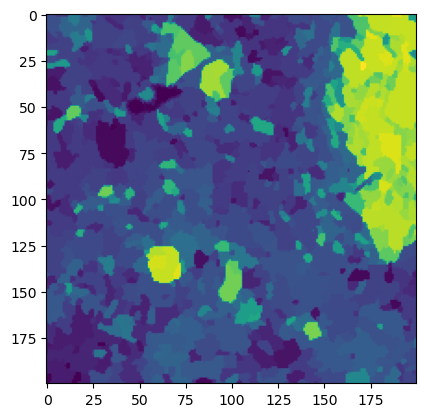

In [256]:
import itertools
plt.imshow(elems_n['Al'][800:1000,800:1000])
def extract_index_from_dict(data_dict, n, m):
    return {key: value[n, m]*100 for key, value in data_dict.items()}
print(extract_index_from_dict(elems_n,900,1000))
print(extract_index_from_dict(elems_n,900,900))
def augment_features(data_dict, alpha=1e-2):
    augmented_dict = {}
    
    # Generate all pairs (x, y) where x ≠ y
    for x_key, y_key in itertools.permutations(data_dict.keys(), 2):
        augmented_key = f"{x_key}_over_{y_key}"  # New feature name
        augmented_dict[augmented_key] = (data_dict[x_key] + alpha) / (data_dict[y_key] + alpha)
    
    return augmented_dict
elems_n_a = augment_features(elems_n,alpha=1e-2)
print(extract_index_from_dict(elems_n_a,900,900))

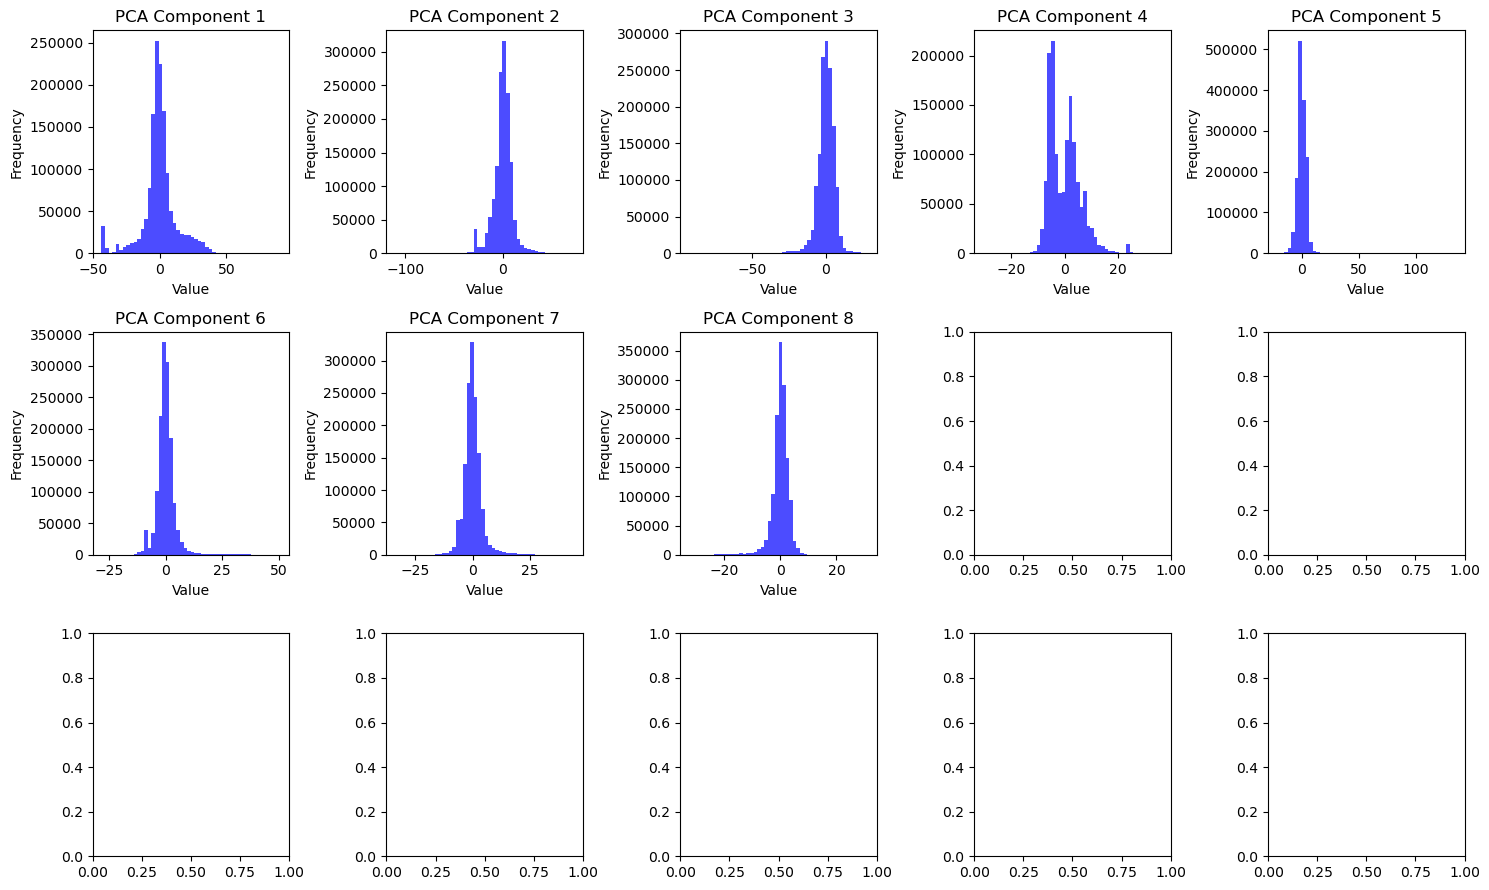

In [297]:
from sklearn.decomposition import PCA
data = np.array([elems_n_a[key][mask] for key in sorted(elems_n_a.keys())]) 

ny, nx = np.shape(elems_n['Al'])
def augment_with_spatial_coordinates(data, dims, alpha):
    """
    Augments the original data by adding spatial coordinates.
    `data`: 3D array with dimensions (channels, height, width)
    `dims`: the dimensions of the data (e.g., (15, 1000, 1000))
    Returns augmented data with spatial coordinates.
    """
    channels, height, width = dims
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    spatial_coordinates = np.stack([x*alpha, y*alpha], axis=-1)[mask,:]
    print(np.shape(spatial_coordinates))
    # Flatten the original data and stack the spatial coordinates
    data_flattened = data.reshape(channels, -1).T  # Shape (height*width, channels)
    augmented_data = spatial_coordinates  # Add spatial information
    
    return augmented_data

#coords = augment_with_spatial_coordinates(np.zeros(np.shape(elems_n_a['Al'])),(1,ny,nx),alpha=5*1e-5)
elems_n_flattened = data.reshape(15*14, -1).T  # Shape (1000000, 15)
#elems_n_flattened = np.hstack([elems_n_flattened, coords])
# Apply PCA
pca = PCA(n_components=8)  # Keep all 15 components
transformed_data = pca.fit_transform(elems_n_flattened[:,:])  # Shape (1000000, 15)

# Explained variance ratio (optional)
explained_variance = pca.explained_variance_ratio_

num_components = transformed_data.shape[1]

# Plot histograms for each PCA component
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 9))  # 3 rows, 5 columns
axes = axes.flatten()  # Flatten to iterate easily

for i in range(num_components):
    axes[i].hist(transformed_data[:, i], bins=50, alpha=0.7, color='b')
    axes[i].set_title(f'PCA Component {i+1}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

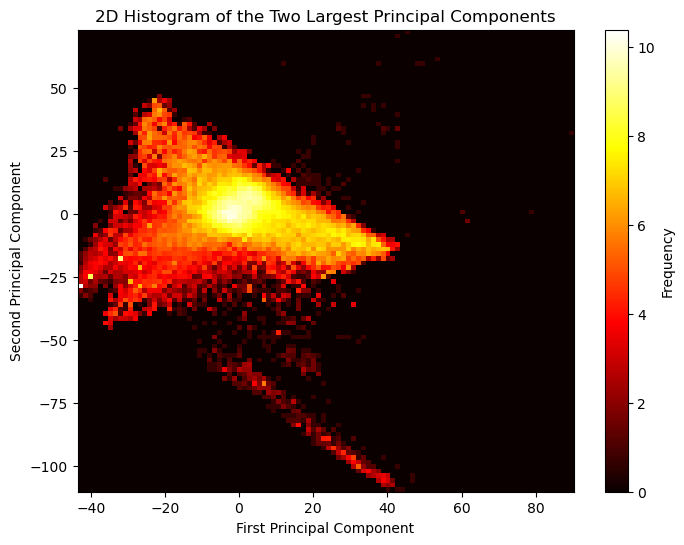

In [298]:
# Select the two largest principal components
pc1 = transformed_data[:, 0]  # First principal component
pc2 = transformed_data[:, 1]  # Second principal component

# Define the number of bins
num_bins = 100  # Adjust as needed

# Compute the 2D histogram
hist, x_edges, y_edges = np.histogram2d(pc1, pc2, bins=num_bins)

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(np.log(hist.T+1), origin='lower', aspect='auto', cmap='hot',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label='Frequency')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D Histogram of the Two Largest Principal Components')
plt.show()

In [299]:
import pandas as pd

# Get principal components (each row corresponds to a component, each column to a feature)
principal_components = pca.components_  # Shape (15, 15)

# Convert to a DataFrame for better readability
pc_df = pd.DataFrame(principal_components, 
                     index=[f"PC{i+1}" for i in range(principal_components.shape[0])], 
                     columns=[f"Feature {i+1}" for i in range(principal_components.shape[1])])

# Print the principal components
print(pc_df)


     Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  Feature 6  \
PC1   0.046987   0.061295   0.155608   0.092352   0.092964   0.045040   
PC2  -0.077735  -0.059168  -0.132650  -0.107042  -0.098896  -0.057613   
PC3  -0.133941  -0.092671  -0.160298  -0.158886  -0.143510  -0.082445   
PC4  -0.014793   0.004803   0.016972   0.068368  -0.014069   0.034352   
PC5   0.237454   0.111584   0.149213   0.139751   0.227364   0.087165   
PC6   0.030207   0.029429   0.058390   0.074637   0.106809   0.044988   
PC7  -0.006884   0.013955  -0.016248   0.018505   0.025019   0.027597   
PC8  -0.141801  -0.033880  -0.048630  -0.031979   0.047835  -0.036324   

     Feature 7  Feature 8  Feature 9  Feature 10  ...  Feature 201  \
PC1   0.029728   0.088855   0.013947    0.145726  ...     0.001117   
PC2  -0.047923  -0.076819  -0.033381   -0.126876  ...    -0.008190   
PC3  -0.078366  -0.094912  -0.055635   -0.203879  ...    -0.008508   
PC4  -0.020100  -0.006412  -0.001185    0.023674  ...     0.00

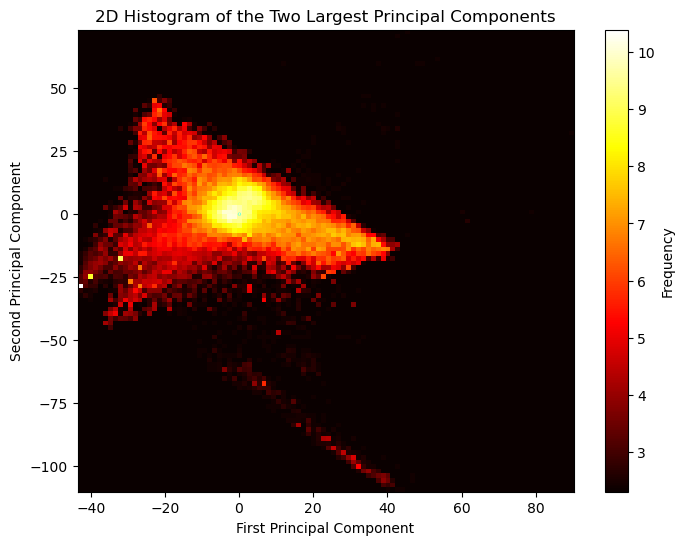

Number of segmented points: 5


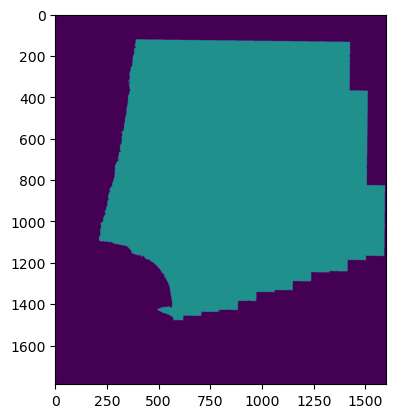

In [300]:
import numpy as np
import matplotlib.pyplot as plt

# Select the two largest principal components
pc1 = transformed_data[:, 0]  # First principal component
pc2 = transformed_data[:, 1]  # Second principal component

# Define the number of bins
num_bins = 100  

# Compute the 2D histogram
hist, x_edges, y_edges = np.histogram2d(pc1, pc2, bins=num_bins)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
heatmap = ax.imshow(np.log(hist.T+10), origin='lower', aspect='auto', cmap='hot',
                     extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(heatmap, label='Frequency')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D Histogram of the Two Largest Principal Components')

# User-defined segmentation parameters
center_x, center_y = +0.11, -0.03  # Replace with chosen center
radius = 0.05  # Adjust as needed

# Plot the segmentation circle
circle = plt.Circle((center_x, center_y), radius, color='cyan', fill=False, linewidth=2)
ax.add_patch(circle)
plt.show()

# **SEGMENTATION STEP**
# Compute distance of all points to the selected center
distances = np.sqrt((pc1 - center_x) ** 2 + (pc2 - center_y) ** 2)
# Create segmentation mask: Points within the circle belong to the class
segmentation_mask = distances < radius
segm_mask_im = np.zeros(np.shape(elems_n['Al']))-1


segm_mask_im[mask] = segmentation_mask

# Apply the mask to get segmented points
segmented_points = transformed_data[segmentation_mask]

# Output segmentation result
print(f"Number of segmented points: {segmented_points.shape[0]}")
plt.imshow(segm_mask_im)
plt.show()


In [301]:
from sklearn.mixture import GaussianMixture
NN = 3
# Select the two largest principal components
pca_data = transformed_data[:, :NN]  # Shape (1000000, n_components_for_pca)

# Fit Gaussian Mixture Model with 2 clusters
num_clusters = 4  # Change if necessary
gmm = GaussianMixture(n_components=num_clusters, covariance_type='full', random_state=42)
gmm.fit(pca_data)

# Predict cluster labels
labels = gmm.predict(pca_data)


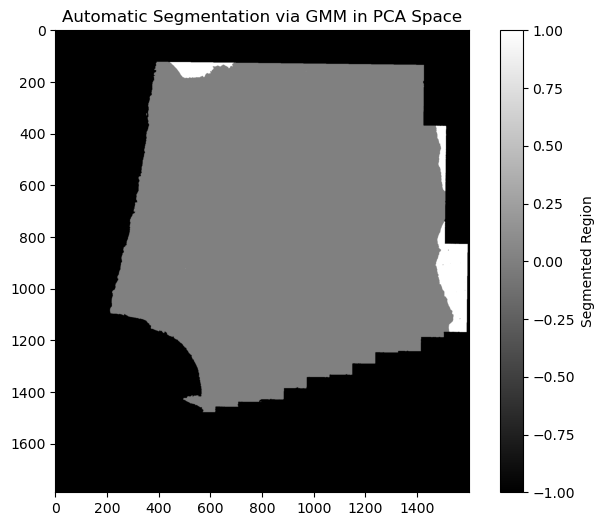

In [303]:


# Choose the dominant cluster (e.g., lowest mean component)
dominant_cluster = np.argmin(gmm.means_[:, 1])  # Smallest PC1 mean
segmentation_mask = labels == dominant_cluster  # Shape (1000000,)

# Reshape segmentation mask to (1000, 1000)
segm_mask_im = np.zeros(np.shape(elems_n['Al']))-1
segm_mask_im[mask] = segmentation_mask

# Plot segmented region
plt.figure(figsize=(8, 6))
plt.imshow(segm_mask_im, cmap='gray')
plt.colorbar(label='Segmented Region')
plt.title('Automatic Segmentation via GMM in PCA Space')
plt.show()

In [314]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

# Function to perform PCA and fit GMM
def pca_gmm_analysis(transformed_data, n_components_for_pca=15, n_components = 2):
    # Use the first `n_components_for_pca` components
    pca_data = transformed_data[:, :n_components_for_pca]  # Shape (1000000, n_components_for_pca)

    # Fit Gaussian Mixture Model with the first `n_components_for_pca` components
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)  # Adjust number of clusters
    gmm.fit(pca_data)

    # Predict cluster labels
    labels = gmm.predict(pca_data)

    # Reshape segmentation mask to (1000, 1000)
    labels_im = np.zeros(np.shape(elems_n['Al']))-1
    labels_im[mask] = labels

    # Return data for plotting and segmentation
    return gmm, pca_data, labels, labels_im

# Function to plot GMM and ellipses for selected principal components
def plot_gmm_ellipses(gmm, pca_data, labels, pc_indices_to_plot=(0, 1)):
    # Select the principal components to plot
    pc1 = pca_data[:, pc_indices_to_plot[0]]  # First selected component
    pc2 = pca_data[:, pc_indices_to_plot[1]]  # Second selected component

    # Plot the scatter plot of the selected components
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot each class with a different color
    scatter = ax.scatter(pc1, pc2, c=labels, cmap='viridis', s=1, alpha=0.5)

    # Plot Gaussian ellipses based on covariance matrices
    for i in range(gmm.n_components):
        mean = gmm.means_[i, pc_indices_to_plot]  # Select means for the chosen PCs
        cov = gmm.covariances_[i][pc_indices_to_plot, pc_indices_to_plot]  # Covariance matrix for the chosen PCs

        # Compute eigenvalues and eigenvectors of the covariance matrix
        if cov.ndim == 1:
            cov = np.diag(cov)  # Convert to diagonal matrix if it is 1D

        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))  # Rotation angle

        # Width and height of ellipse (scaled by standard deviation)
        width, height = 2 * np.sqrt(eigenvalues)  # 1 standard deviation

        # Create and add the ellipse to the plot
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='cyan', facecolor='none', linewidth=2)
        ax.add_patch(ellipse)

    # Display the plot with the colorbar
    plt.colorbar(scatter, label='Cluster Label')
    plt.xlabel(f'Principal Component {pc_indices_to_plot[0] + 1}')
    plt.ylabel(f'Principal Component {pc_indices_to_plot[1] + 1}')
    plt.title(f'GMM Clustering with Covariance Ellipses for Selected Components')
    plt.show()


# Choose number of components for PCA and for plotting
n_components_for_pca = 8  # Number of components for PCA
n_components = 8
# Perform PCA, GMM, and segmentation
gmm, pca_data, labels, segmentation_mask_reshaped = pca_gmm_analysis(transformed_data, 
                                                                     n_components_for_pca=n_components_for_pca, 
                                                                     n_components = n_components)


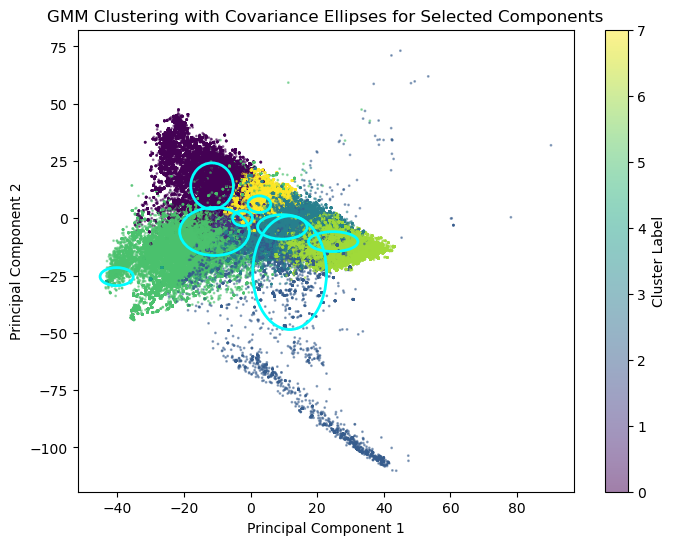

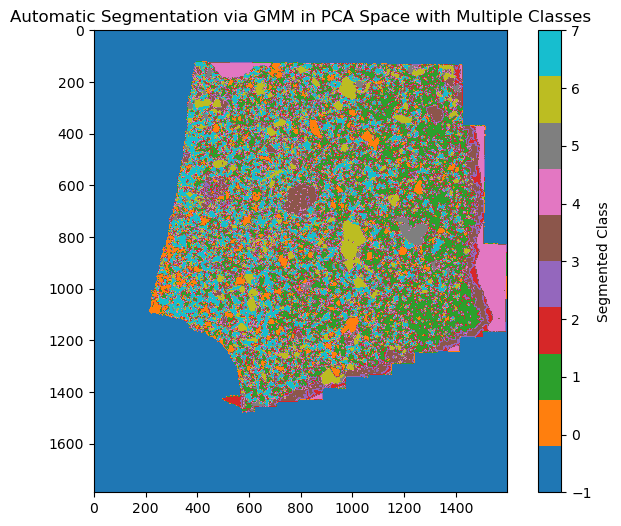

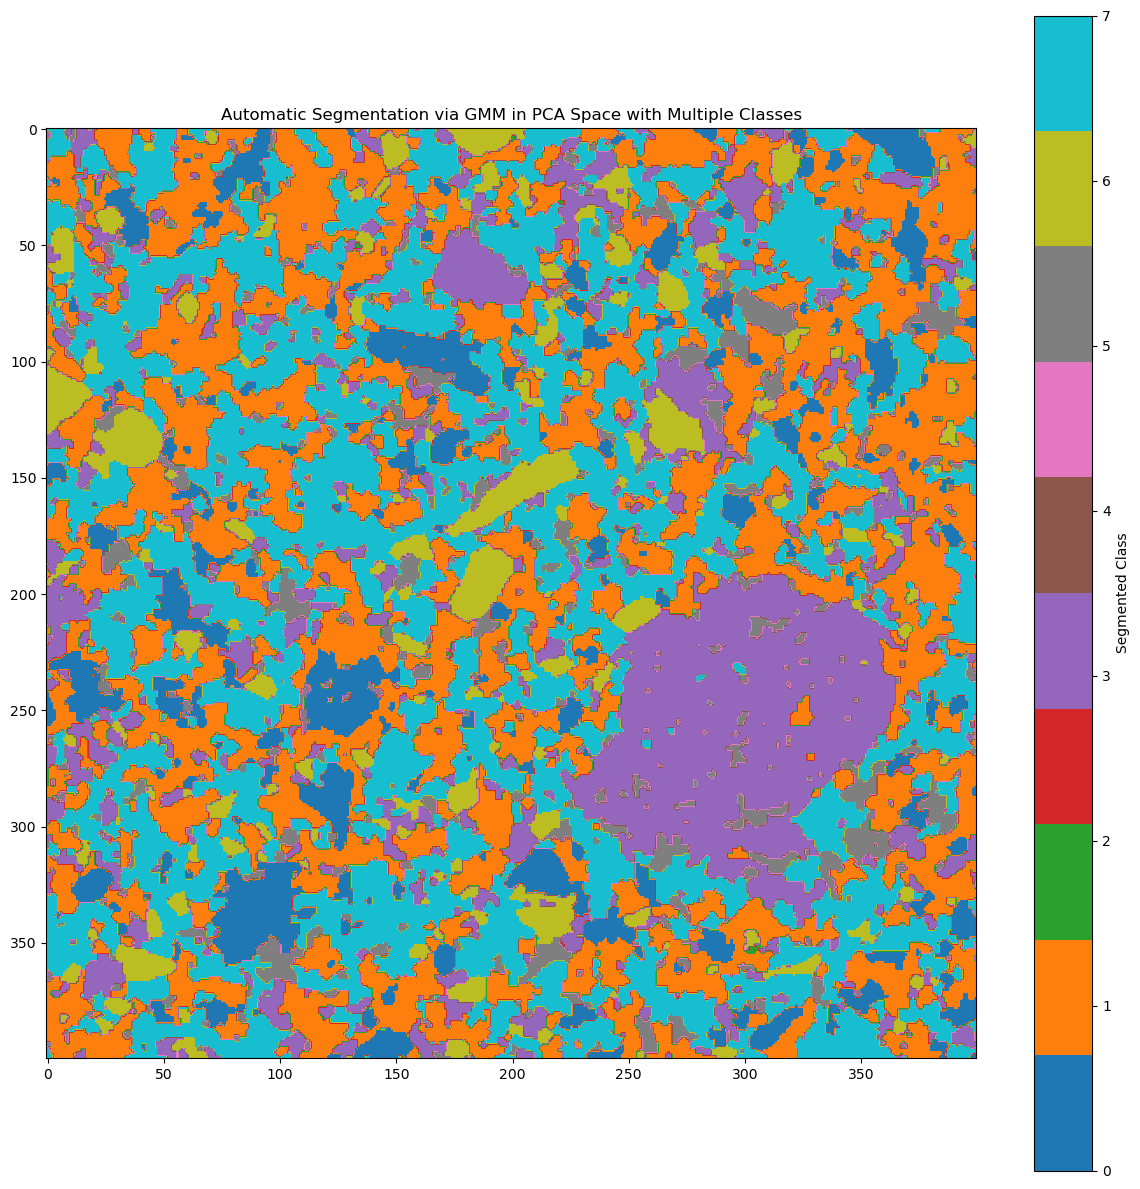

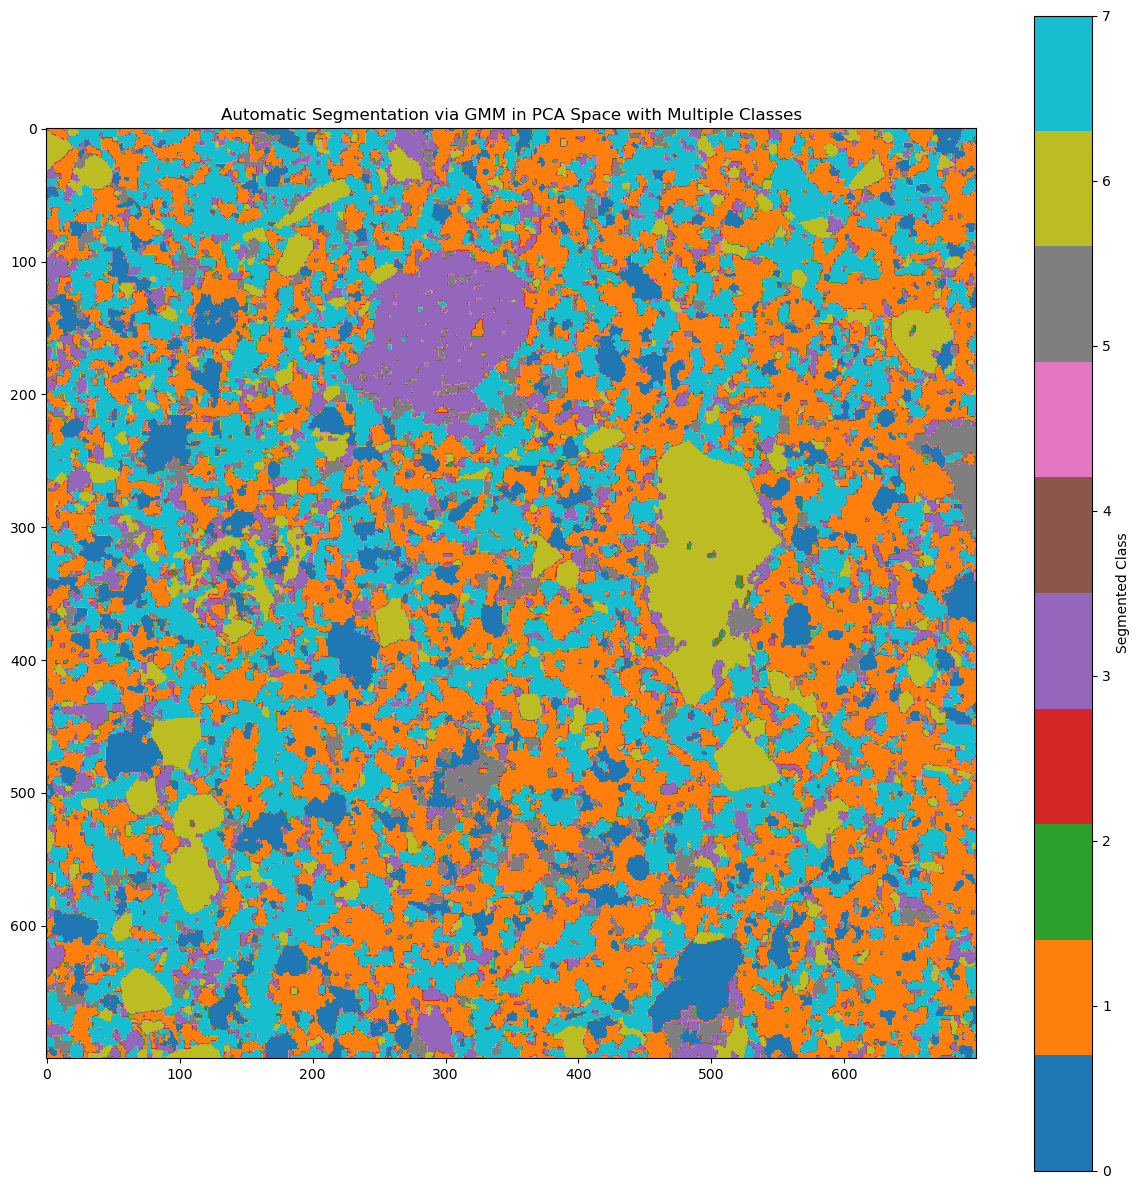

In [315]:
pc_indices_to_plot = (0, 1) 
# Plot the results for selected principal components
plot_gmm_ellipses(gmm, pca_data, labels, pc_indices_to_plot=pc_indices_to_plot)

# Plot the segmented regions in the original shape (all classes)
plt.figure(figsize=(8, 6))
plt.imshow(segmentation_mask_reshaped, cmap='tab10')  # Use a colormap for multiple classes
plt.colorbar(label='Segmented Class')
plt.title('Automatic Segmentation via GMM in PCA Space with Multiple Classes')
plt.show()

# Plot the segmented regions in the original shape (all classes)
plt.figure(figsize=(15, 15))
plt.imshow(segmentation_mask_reshaped[400:800,500:900], cmap='tab10')  # Use a colormap for multiple classes
plt.colorbar(label='Segmented Class')
plt.title('Automatic Segmentation via GMM in PCA Space with Multiple Classes')
plt.show()

# Plot the segmented regions in the original shape (all classes)
plt.figure(figsize=(15, 15))
plt.imshow(segmentation_mask_reshaped[500:1200,500:1200], cmap='tab10')  # Use a colormap for multiple classes
plt.colorbar(label='Segmented Class')
plt.title('Automatic Segmentation via GMM in PCA Space with Multiple Classes')
plt.show()


[0.01335859 0.15653338]
[0.01124735 0.0790437 ]
[0.0029333  0.03962855]
[0.07023021 0.50270619]
[0.01464404 0.09956428]
[0.07341546 0.81032583]


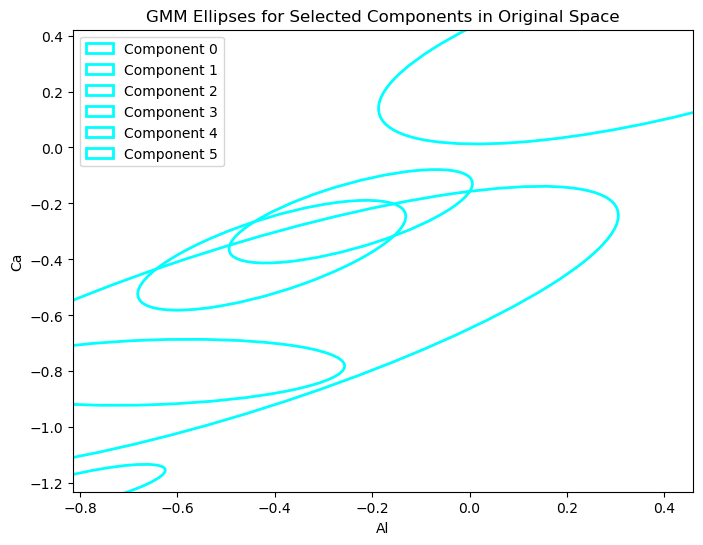

In [295]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_gmm_ellipses_in_original_space(gmm, pca, component_indices, original_basis_idx, n_components_for_pca):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Variables to track the plot limits
    min_x, max_x, min_y, max_y = np.inf, -np.inf, np.inf, -np.inf

    # Loop over all the components in the provided list of GMM components
    for component_idx in component_indices:
        # Retrieve the mean and covariance matrix of the i-th Gaussian mixture component (in PCA space)
        mean_pca = gmm.means_[component_idx]
        cov_pca = gmm.covariances_[component_idx]

        # Extend the mean and covariance to the full PCA space (15 components)
        mean_extended = np.zeros(n_components_for_pca)
        cov_extended = np.zeros((n_components_for_pca, n_components_for_pca))
        
        mean_extended[:mean_pca.shape[0]] = mean_pca  # Extend the mean to the full space
        cov_extended[:cov_pca.shape[0], :cov_pca.shape[1]] = cov_pca  # Extend the covariance matrix

        # Apply the inverse PCA transformation to map the results back to the original space
        mean_original = np.dot(pca.components_.T, mean_extended)
        cov_original = np.dot(np.dot(pca.components_.T, cov_extended), pca.components_)

        # Extract the submatrix and subvector corresponding to the selected original components
        cov_selected = cov_original[np.ix_(original_basis_idx, original_basis_idx)]  # Extract 2x2 submatrix
        mean_selected = mean_original[original_basis_idx]  # Extract the corresponding mean values

        # Compute eigenvalues and eigenvectors of the covariance matrix (in original space)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_selected)

        # Compute the angle of rotation for the ellipse
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))  # Rotation angle

        # Compute the width and height of the ellipse (2 standard deviations)
        width, height = 2 * np.sqrt(np.sort(eigenvalues))
        print(np.sort(eigenvalues))
        # Plot the ellipse in the original space
        ellipse = Ellipse(xy=mean_selected, width=width, height=height, angle=angle,
                          edgecolor='cyan', facecolor='none', linewidth=2, label=f'Component {component_idx}')
        ax.add_patch(ellipse)

        # Update plot limits based on the current ellipse
        min_x = min(min_x, mean_selected[0] -0.005)#- 1.5 * width)
        max_x = max(max_x, mean_selected[0] +0.005)#+ 1.5 * width)
        min_y = min(min_y, mean_selected[1] -0.005)#- 1.5 * height)
        max_y = max(max_y, mean_selected[1] +0.005)#+ 1.5 * height)

    # Set the plot limits based on the minimum and maximum values from all ellipses
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    
    ax.set_xlabel(elements[original_basis_idx[0]])
    ax.set_ylabel(elements[original_basis_idx[1]])
    plt.title('GMM Ellipses for Selected Components in Original Space')
    ax.legend()
    plt.show()

# Example usage:
# Assume you already have the gmm and pca from earlier
plot_gmm_ellipses_in_original_space(gmm, pca, component_indices=[0, 1, 2,3,4,5], original_basis_idx=[0, 1], n_components_for_pca=15)
